In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

import matplotlib
import matplotlib.pyplot as plt

In [2]:
#set up cosmology

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### Scale factor grids for comoving distance

These distances are firstly calculated and used as a interpolation table to inquire the $\chi(z)$ or $z(\chi)$

#### CCL
||Linear grids|Log grids|
|:---|:---|:---|
|a|$(1e-4,0.1)$|$(0.1,1)$|
|Number|$250$ | $250$|

#### COCOA
||Linear grids|Linear grids|Linear grids|
|:---|:---|:---|:---|
|z|$(0,3.0)$|$(3.0,50.1)$|$(1070,1100)$|
|Number|$1000$| $500$|$125$|

Redshift $(0,50)$ contributes most to 3x2pt, while the redshift $(1070,1100)$ is for CMB probe.


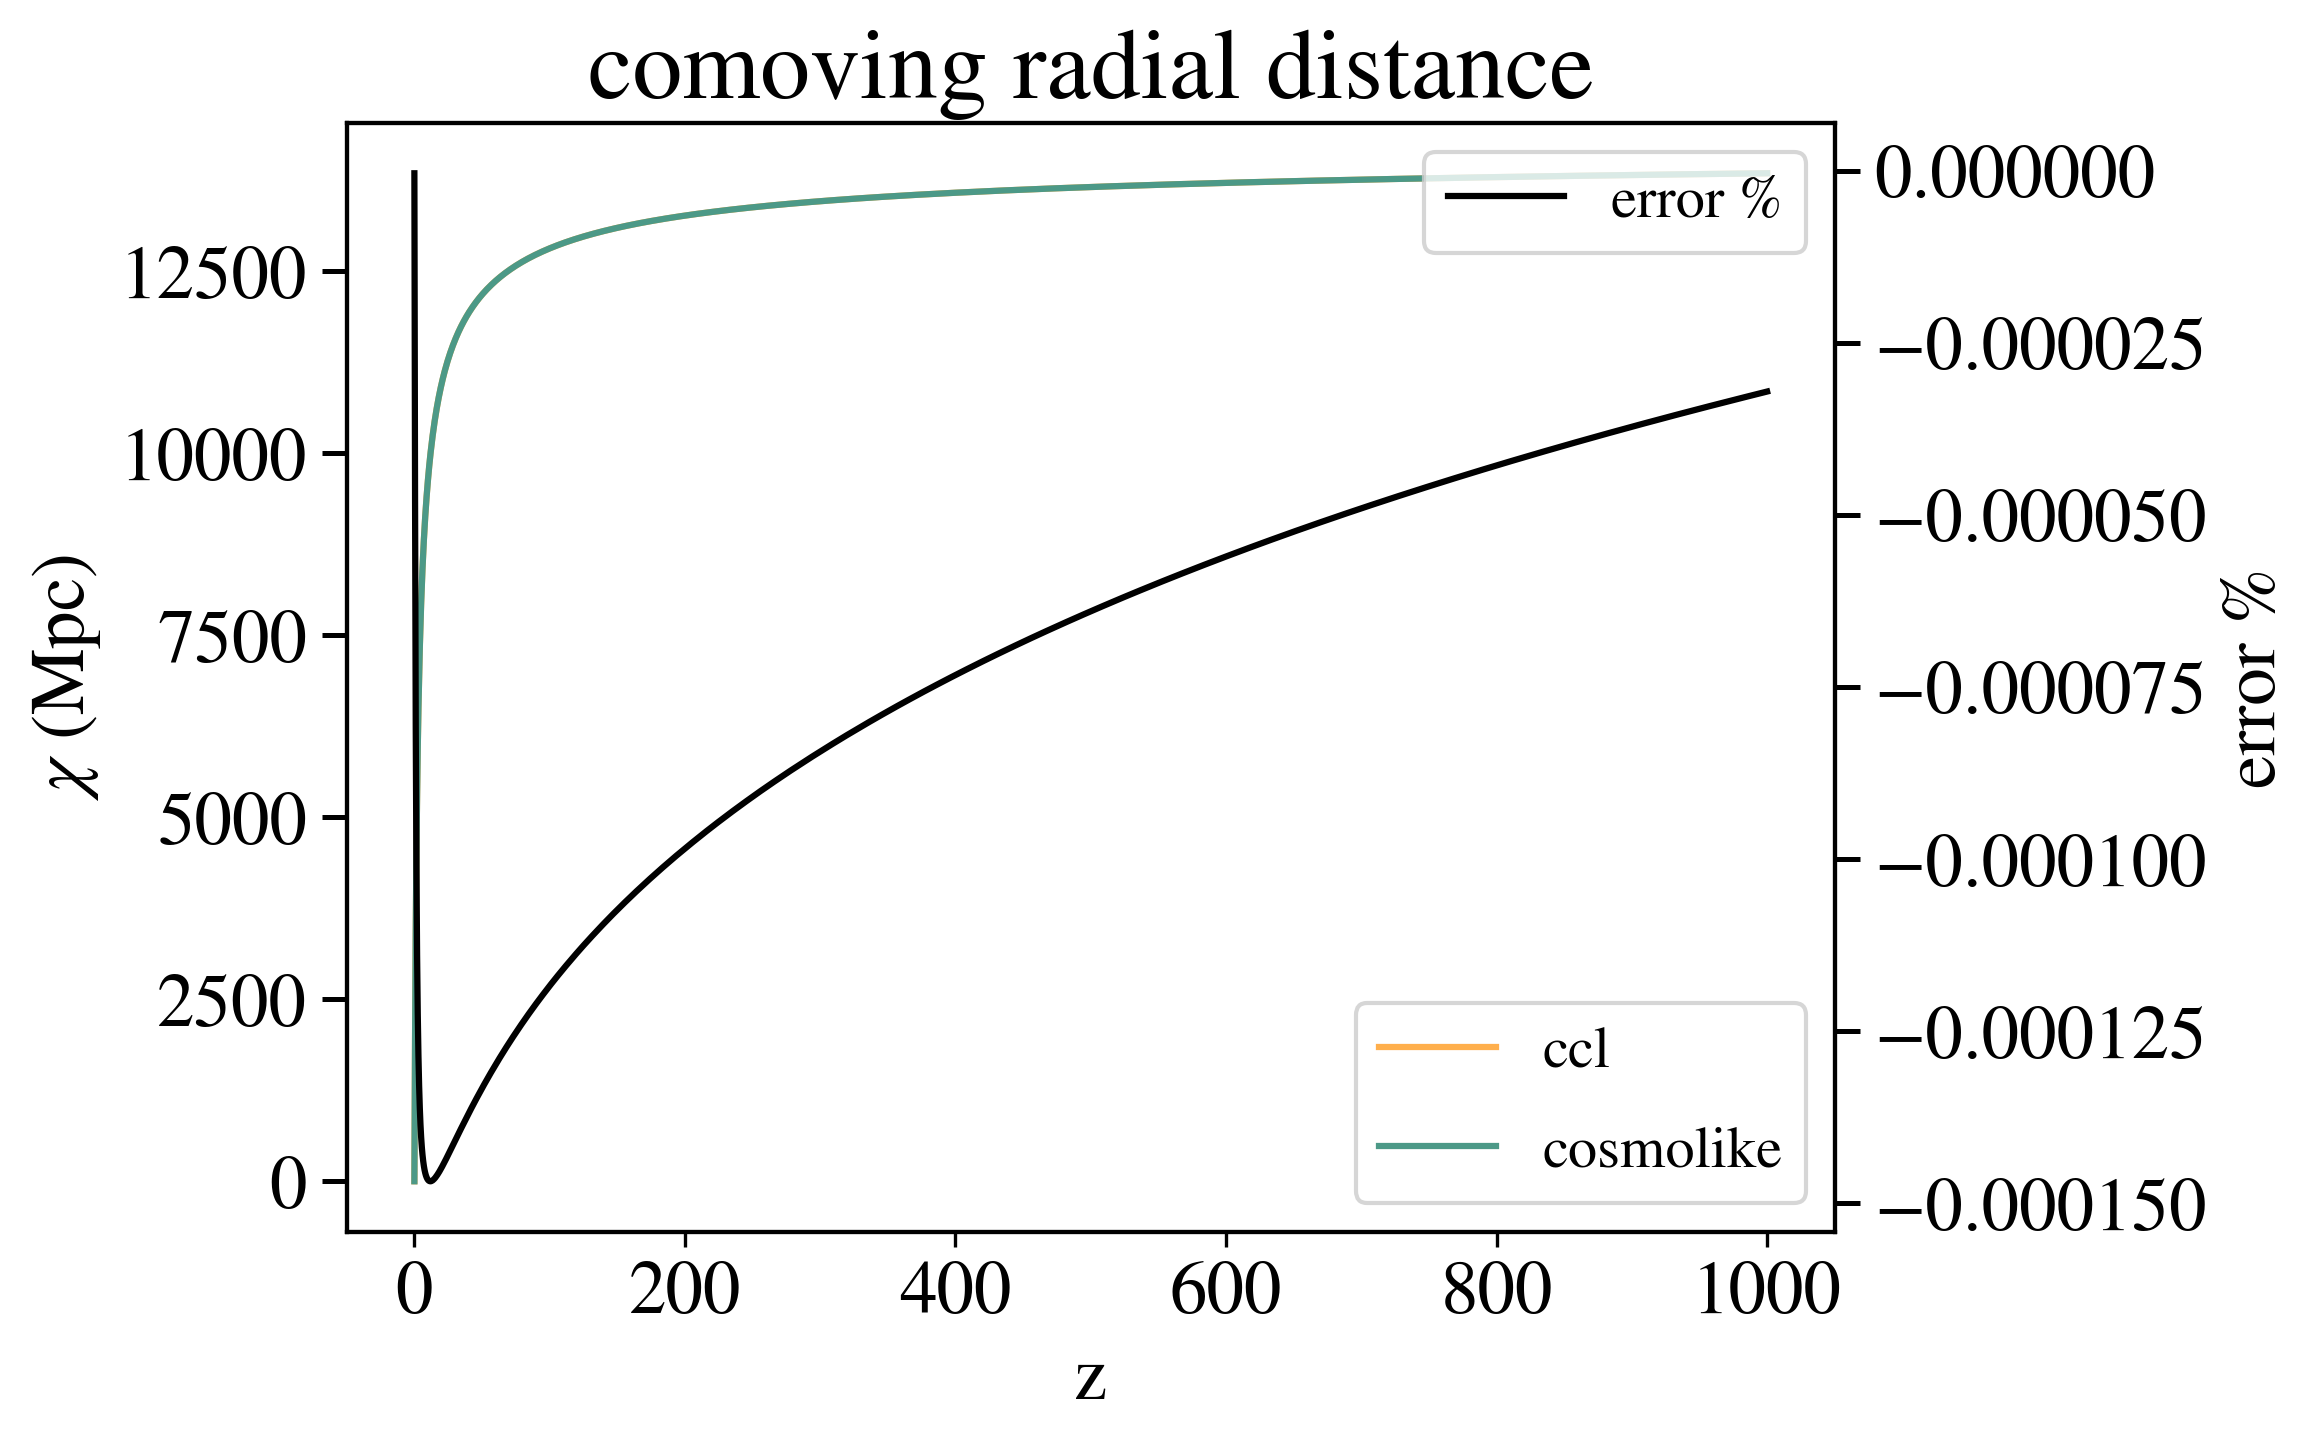

In [13]:
#-------------------------------------------------------------------------#
#-----------you are not supposed to reproduce this picture----------------#
#-------------------------------------------------------------------------#
'''
filepath = './cocoa/Cocoa/projects/roman_fourier/chains/roman_setup0_evaluate/'
zs_cosmolike = np.loadtxt(filepath+'z_chi.txt')
chis_cosmolike = np.loadtxt(filepath+'chi_z.txt')/h

a_s_ccl = np.concatenate((np.exp(np.linspace(np.log(1e-4), np.log(0.1), 250)), np.linspace(0.1,1,250)))
zs_ccl = (1/np.concatenate((np.exp(np.linspace(np.log(1e-4), np.log(0.1), 250)), np.linspace(0.1,1,250)))-1)[::-1]
chis_ccl = COSMO.comoving_radial_distance(a_s_ccl)[::-1]

#build a interpolator for easire comparison
from scipy.interpolate import interp1d
f_ccl = interp1d(zs_ccl, chis_ccl)
f_cosmolike = interp1d(zs_cosmolike, chis_cosmolike)
zs = np.linspace(1e-4,1000,2000)
ys_ccl = f_ccl(zs)
ys_cosmolike = f_cosmolike(zs)

fig, ax1 = plt.subplots()
ax1.plot(zs, ys_ccl, color='#FFAF4C', label='ccl')
ax1.plot(zs, ys_cosmolike, color='#4C9987', label='cosmolike')
ax1.set_xlabel('z')
ax1.set_ylabel(r'$\chi$ (Mpc)')
ax1.legend()
    
ax2 = ax1.twinx()
ax2.plot(zs, (ys_cosmolike-ys_ccl)/ys_ccl*100, color='k', label='error %')
ax2.set_ylabel('error %')
ax2.legend()

plt.title('comoving radial distance')
plt.show()
'''
from IPython.display import Image, display
display(Image(filename='./pic/comoving-radial-distance.png'))

### Conclusion

It shows that CCL and COCOA's comoving radial distance align very well that the error is smaller than 0.0002%, though the error reaches its maximum at $z\sim10$ or $a\sim0.1$. I am not sure if this is a numerical error or something subtle in the Hubble rate. However one thing I notice that they use different normalization factor for neutrino density parameter, i.e $\Omega_\nu = \frac{\sum m_\nu}{\mathrm{Norm}}$. the normalization factor inside CCL is aligned with CLASS while COCOA's comoving distance is provided by CAMB. 

### Modification

No modification here. One possible thing we could do is aligning the scale factor grids for comoving distance in both pipelines. However further test shows there is no noticable improvements on $\chi^2$ (see the tables below), and this grids maybe is chosen to be pipeline-self-consistent, therefore we don't modify the grids here.



- Employ CCL's scale factor grids to COCOA
||$C_\ell^{ss}$|$C_\ell^{gs}$|$C_\ell^{gg}$|
|:---|:---|:---|:---|
|$\chi^2$|0.054|0.063|0.093|
|$\chi^2_\mathrm{mask}$|0.006|0.021|0.028|

- Use their origin scale factor grids
||$C_\ell^{ss}$|$C_\ell^{gs}$|$C_\ell^{gg}$|
|:---|:---|:---|:---|
|$\chi^2$|0.052|0.063|0.078|
|$\chi^2_\mathrm{mask}$|0.006|0.021|0.028|

### Next step

Check the radial kernel


In [9]:
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300